CLase 4-3-26

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_8968\1140083060.py:34: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


<function matplotlib.pyplot.show(close=None, block=None)>

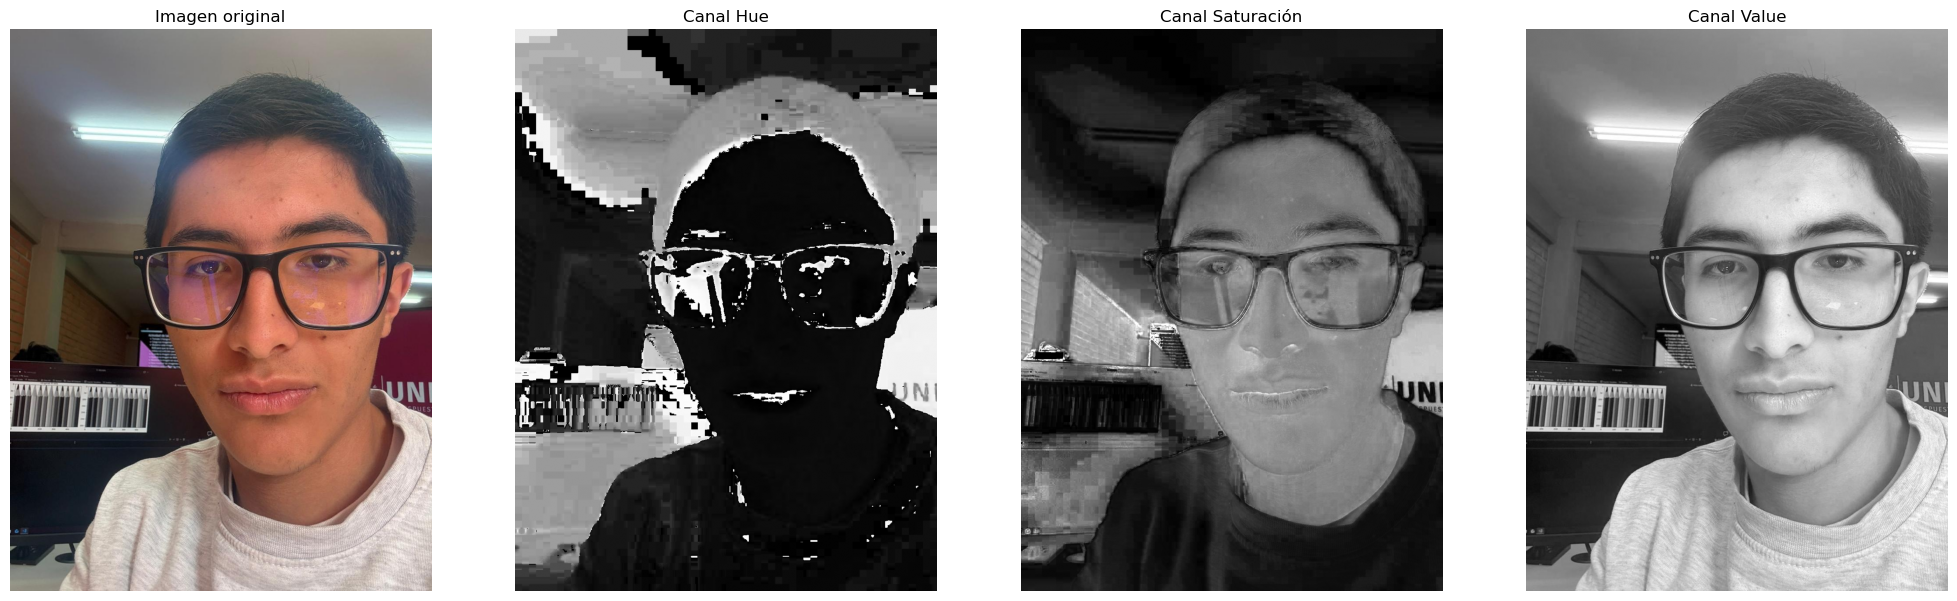

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen1 = cv2.imread('imagen1_bgr.jpg')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img
hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

for ax in axs:
    ax.axis('off')
plt.show

rgb a hsv

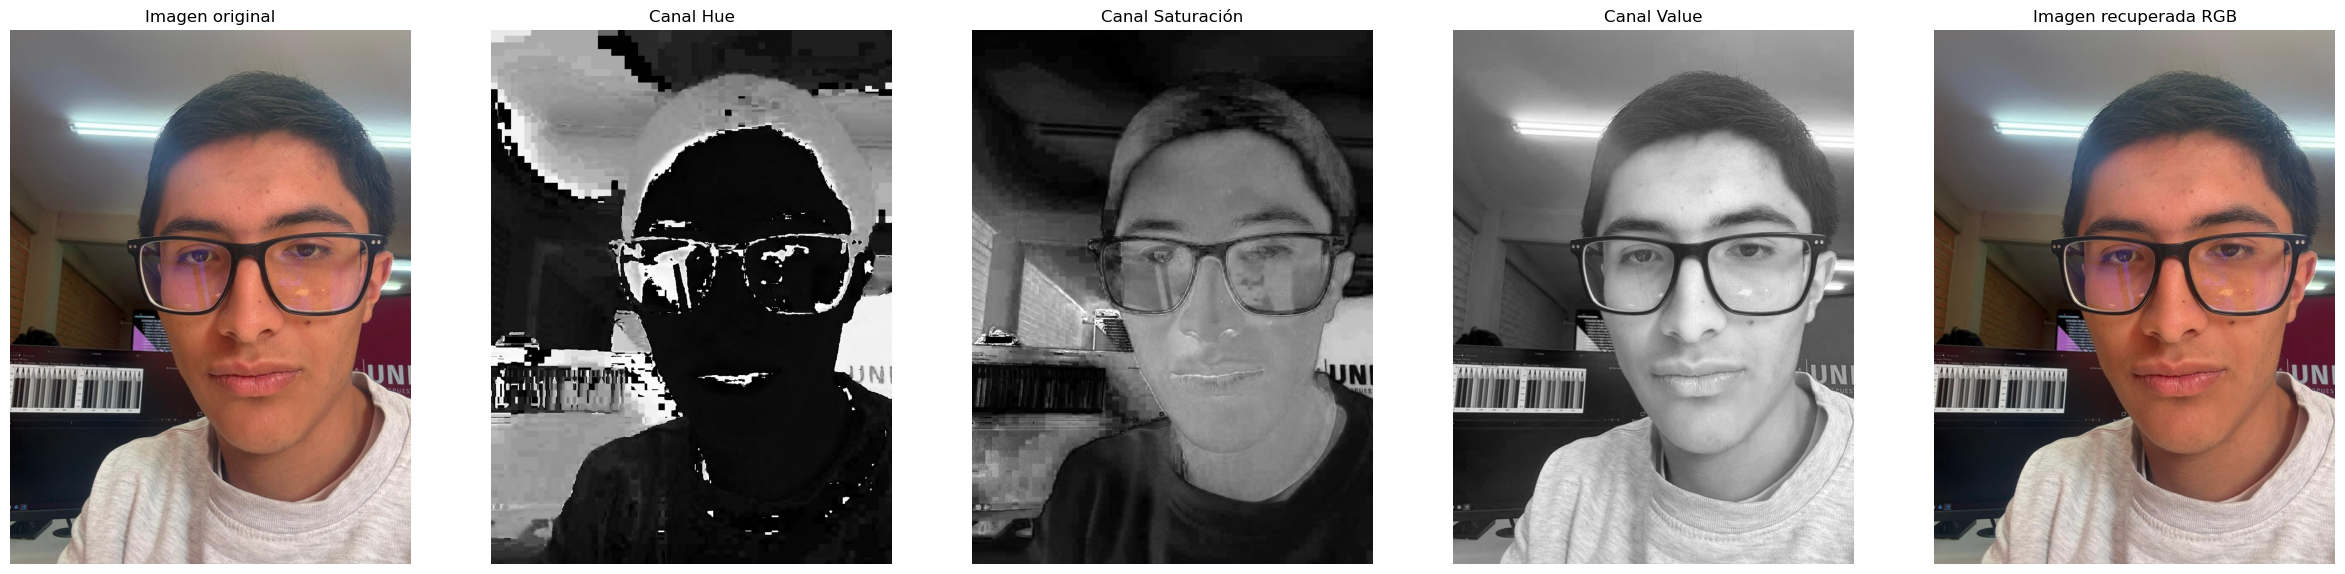

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


imagen1 = cv2.imread('imagen1_bgr.jpg')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)


def RGB2HSV(img):
    img = img.astype(np.float32) / 255.0
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    # VALUE
    new_img[..., 2] = maxValue

    # SATURACIÓN
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i, j] == 0:
                new_img[i, j, 1] = 0
            else:
                new_img[i, j, 1] = (maxValue[i, j] - minValue[i, j]) / maxValue[i, j]

    # HUE
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            if maxValue[i, j] == minValue[i, j]:
                new_img[i, j, 0] = 0

            elif maxChannel[i, j] == 0:  # R
                new_img[i, j, 0] = 60 * ((img[i, j, 1] - img[i, j, 2]) /
                                         (maxValue[i, j] - minValue[i, j]))

            elif maxChannel[i, j] == 1:  # G
                new_img[i, j, 0] = 120 + 60 * ((img[i, j, 2] - img[i, j, 0]) /
                                               (maxValue[i, j] - minValue[i, j]))

            elif maxChannel[i, j] == 2:  # B
                new_img[i, j, 0] = 240 + 60 * ((img[i, j, 0] - img[i, j, 1]) /
                                               (maxValue[i, j] - minValue[i, j]))

            if new_img[i, j, 0] < 0:
                new_img[i, j, 0] += 360

    return new_img



def HSV2RGB(hsv_img):

    h = hsv_img[..., 0]
    s = hsv_img[..., 1]
    v = hsv_img[..., 2]

    rgb = np.zeros_like(hsv_img)

    c = v * s
    x = c * (1 - np.abs((h / 60) % 2 - 1))
    m = v - c

    for i in range(h.shape[0]):
        for j in range(h.shape[1]):

            if 0 <= h[i, j] < 60:
                r_, g_, b_ = c[i, j], x[i, j], 0
            elif 60 <= h[i, j] < 120:
                r_, g_, b_ = x[i, j], c[i, j], 0
            elif 120 <= h[i, j] < 180:
                r_, g_, b_ = 0, c[i, j], x[i, j]
            elif 180 <= h[i, j] < 240:
                r_, g_, b_ = 0, x[i, j], c[i, j]
            elif 240 <= h[i, j] < 300:
                r_, g_, b_ = x[i, j], 0, c[i, j]
            else:
                r_, g_, b_ = c[i, j], 0, x[i, j]

            rgb[i, j, 0] = r_ + m[i, j]
            rgb[i, j, 1] = g_ + m[i, j]
            rgb[i, j, 2] = b_ + m[i, j]

    return (rgb * 255).astype(np.uint8)



hsv_img = RGB2HSV(img)
rgb_recuperada = HSV2RGB(hsv_img)

fig, axs = plt.subplots(1, 5, figsize=(30, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

axs[4].imshow(rgb_recuperada)
axs[4].set_title('Imagen recuperada RGB')

for ax in axs:
    ax.axis('off')

plt.show()

Nuevas imagenes

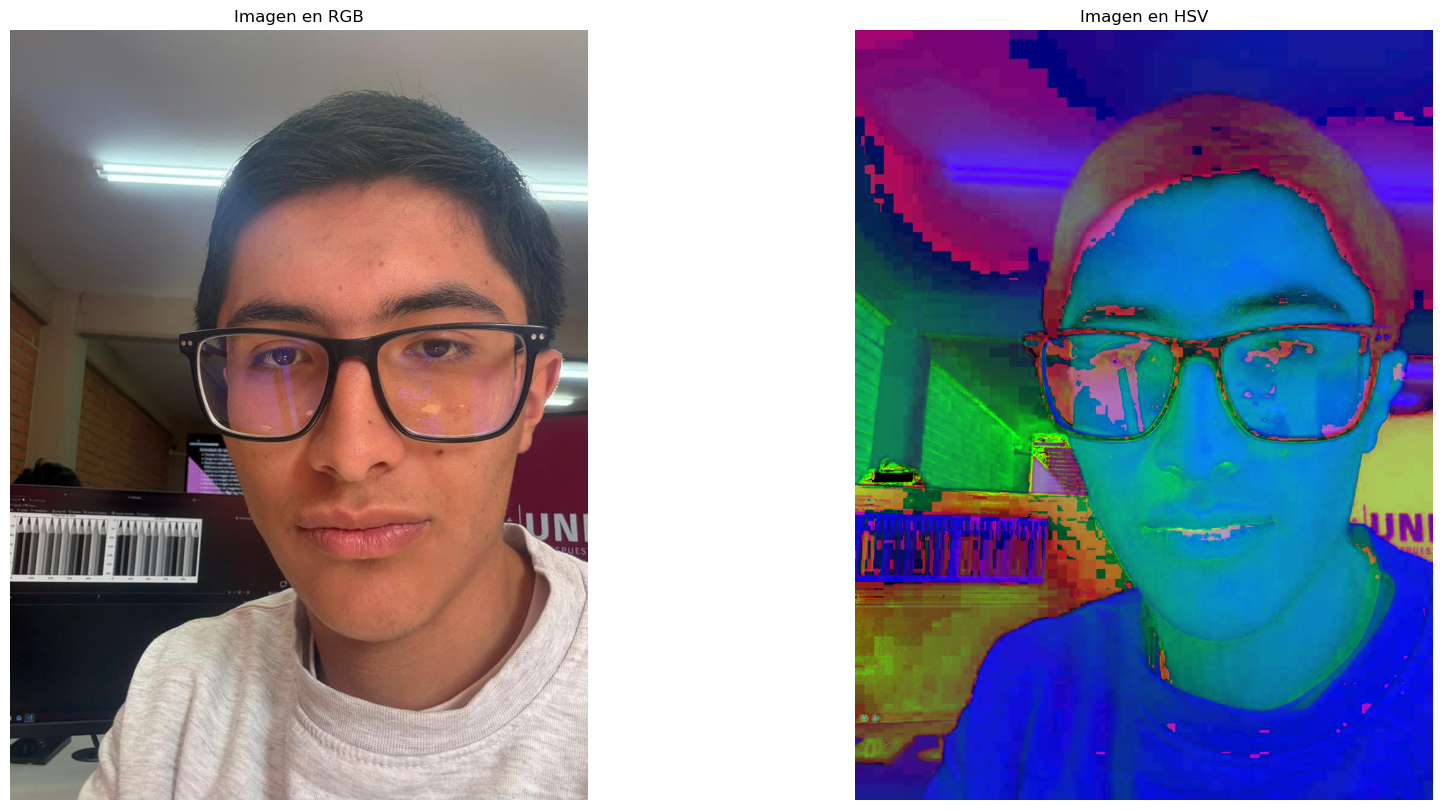

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(cv2.imread('imagen1_bgr.jpg', cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagen en RGB")
axs[0].axis("off")

axs[1].imshow(img_hsv)
axs[1].set_title("Imagen en HSV")
axs[1].axis("off")


plt.show()

Practica 3.1

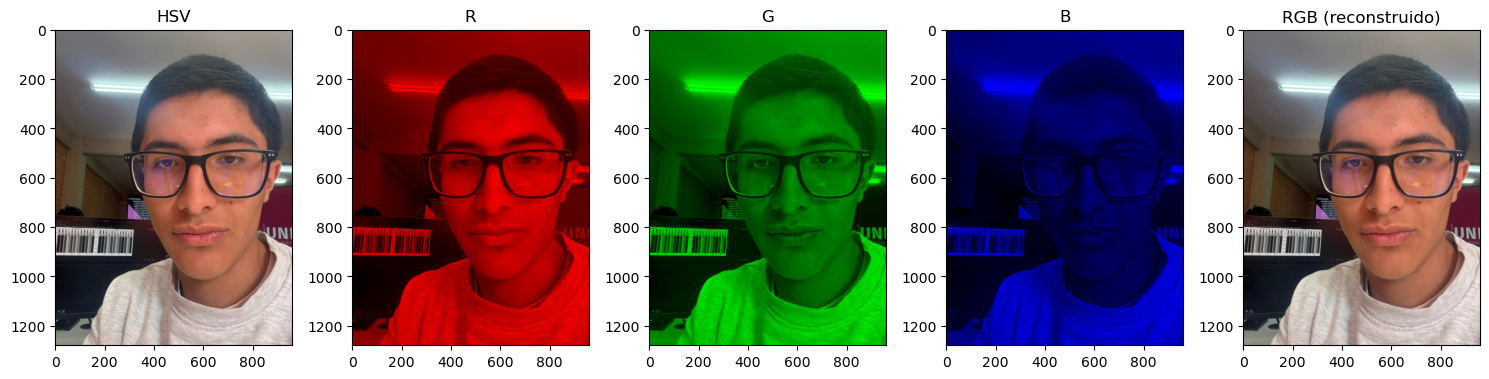

In [26]:
#EJERCICIO 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

def hsv_opencv_a_rgb_formula(img_bgr):

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    H = hsv[:, :, 0].astype(np.float32)
    S = hsv[:, :, 1].astype(np.float32)
    V = hsv[:, :, 2].astype(np.float32)

    H_deg = H * 2.0
    S_n = S / 255.0
    V_n = V / 255.0

    C = V_n * S_n
    H_ = H_deg / 60.0
    X = C * (1.0 - np.abs((H_ % 2.0) - 1.0))
    m = V_n - C

    Rp = np.zeros_like(H_, dtype=np.float32)
    Gp = np.zeros_like(H_, dtype=np.float32)
    Bp = np.zeros_like(H_, dtype=np.float32)

    s0 = (0.0 <= H_) & (H_ < 1.0)
    s1 = (1.0 <= H_) & (H_ < 2.0)
    s2 = (2.0 <= H_) & (H_ < 3.0)
    s3 = (3.0 <= H_) & (H_ < 4.0)
    s4 = (4.0 <= H_) & (H_ < 5.0)
    s5 = (5.0 <= H_) & (H_ < 6.0)

    Rp[s0], Gp[s0], Bp[s0] = C[s0], X[s0], 0.0
    Rp[s1], Gp[s1], Bp[s1] = X[s1], C[s1], 0.0
    Rp[s2], Gp[s2], Bp[s2] = 0.0, C[s2], X[s2]
    Rp[s3], Gp[s3], Bp[s3] = 0.0, X[s3], C[s3]
    Rp[s4], Gp[s4], Bp[s4] = X[s4], 0.0, C[s4]
    Rp[s5], Gp[s5], Bp[s5] = C[s5], 0.0, X[s5]

    R = np.clip((Rp + m) * 255.0, 0, 255).astype(np.uint8)
    G = np.clip((Gp + m) * 255.0, 0, 255).astype(np.uint8)
    B = np.clip((Bp + m) * 255.0, 0, 255).astype(np.uint8)

    rgb_formula = np.dstack([R, G, B])

    r = rgb_formula[:,:,0]
    g = rgb_formula[:,:,1]
    b = rgb_formula[:,:,2]

    r_img = np.zeros_like(rgb_formula)
    g_img = np.zeros_like(rgb_formula)
    b_img = np.zeros_like(rgb_formula)

    r_img[:,:,0] = r
    g_img[:,:,1] = g
    b_img[:,:,2] = b

    return hsv, rgb_formula, r_img, g_img, b_img


def mostrar_1(img_path):

    img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)

    hsv, rgb_formula, r_img, g_img, b_img = hsv_opencv_a_rgb_formula(img_bgr)

    hsv_show = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    plt.figure(figsize=(15,5))

    plt.subplot(1,5,1)
    plt.title("HSV")
    plt.imshow(hsv_show)

    plt.subplot(1,5,2)
    plt.title("R")
    plt.imshow(r_img)

    plt.subplot(1,5,3)
    plt.title("G")
    plt.imshow(g_img)

    plt.subplot(1,5,4)
    plt.title("B")
    plt.imshow(b_img)

    plt.subplot(1,5,5)
    plt.title("RGB (reconstruido)")
    plt.imshow(rgb_formula)

    plt.tight_layout()
    plt.show()


mostrar_1("imagen1.jpg")